In [2]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

# Representational geometry at session 3
*Compare with model components below

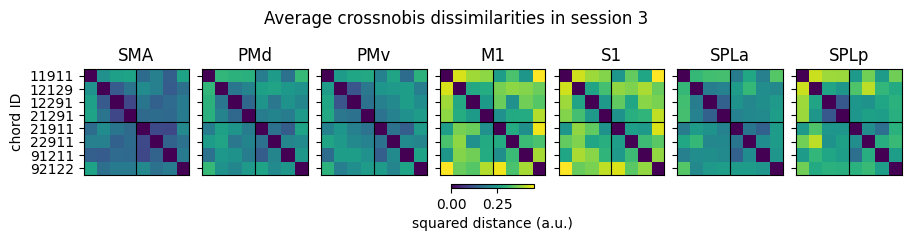

In [7]:
session = 3

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.3))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=gl.chordID)
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

axs[0].set_ylabel('chord ID')

fig.colorbar(im, ax=axs, fraction=.03, label='squared distance (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3')

fig.savefig(f'figures/crossnobis_example_{sn}.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords (ROI-based)
In M1, activity patterns for trained chords on session 23 are slightly more distant among each other compared to untrained chords. This difference is not reliable across participants

           T  dof     p_val           CI95   roi  session
0  -0.536513   15  0.599471  [-0.02, 0.01]   SMA        3
3  -0.339298   15  0.739089  [-0.02, 0.01]   PMd        3
6  -0.512439   15  0.615806  [-0.03, 0.02]   PMv        3
9  -0.316506   15  0.755981  [-0.05, 0.04]    M1        3
12 -0.622612   15  0.542890  [-0.04, 0.02]    S1        3
15 -1.163322   15  0.262871  [-0.05, 0.01]  SPLa        3
18 -0.865556   15  0.400366  [-0.05, 0.02]  SPLp        3
1   0.171311   15  0.866269  [-0.02, 0.02]   SMA        9
4  -1.050129   15  0.310284  [-0.03, 0.01]   PMd        9
7  -0.196098   15  0.847165  [-0.03, 0.03]   PMv        9
10  0.926154   15  0.369028  [-0.02, 0.05]    M1        9
13  0.860983   15  0.402801  [-0.03, 0.06]    S1        9
16 -0.035643   15  0.972037  [-0.03, 0.03]  SPLa        9
19 -0.145276   15  0.886427  [-0.03, 0.03]  SPLp        9
2  -0.843297   15  0.412309  [-0.01, 0.01]   SMA       23
5  -0.383190   15  0.706955  [-0.02, 0.01]   PMd       23
8  -2.028013  

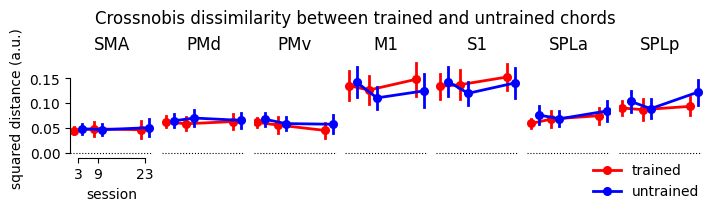

In [19]:
hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem=='L') & (dist.chord.isin(hue_order))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

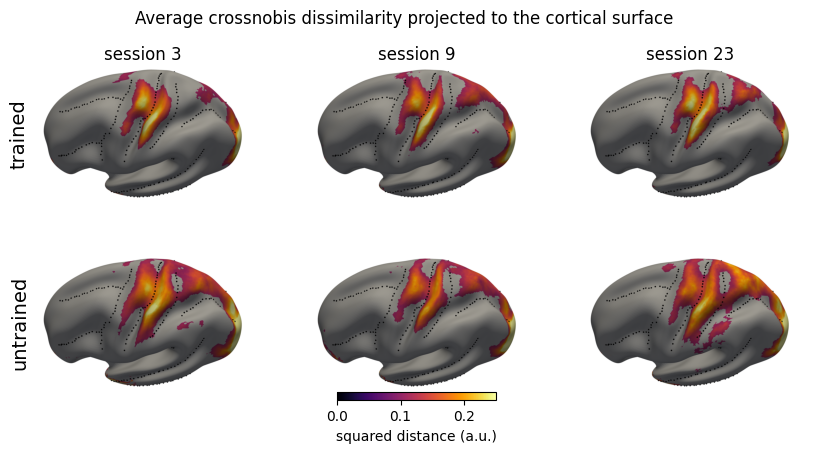

In [32]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('crossnobis-trained')
    untr_col = cols.index('crossnobis-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

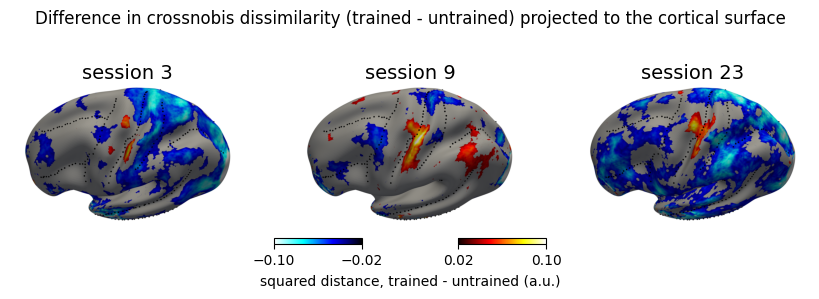

In [33]:
cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold        = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot         = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals   = cold(np.linspace(1, 0, 128))  # reversed
combined    = np.vstack((cold_vals, hot))
cmap        = LinearSegmentedColormap.from_list('coldhot', combined)

thresh = .02
vmin, vmax = -.1, .1

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3), )

for s, session in enumerate(gl.sessions):
    ax       = axs[s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis_diff.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    diff_col = cols.index('trained-untrained')
    plot_surf(fig, ax, gifti, H, cmap=cmap, col=diff_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax.set_title(f'session {session}', fontsize=14)

cold_half = LinearSegmentedColormap.from_list('cold_half', combined[:128])
hot_half  = LinearSegmentedColormap.from_list('hot_half', combined[128:])

sm_neg   = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=-thresh), cmap=cold_half)
cax_neg  = fig.add_axes([.33, .2, .11, .02])
cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])

sm_pos   = plt.cm.ScalarMappable(norm=Normalize(vmin=thresh, vmax=vmax), cmap=hot_half)
cax_pos  = fig.add_axes([.56, .2, .11, .02])
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])

fig.supxlabel('squared distance, trained - untrained (a.u.)', fontsize=10, y=.05)

fig.suptitle('Difference in crossnobis dissimilarity (trained - untrained) projected to the cortical surface')

plt.subplots_adjust(left=0, right=1, bottom=.1, top=.9, hspace=0)

fig.savefig('figures/crossnobis_diff_searchlight.pdf')

plt.show()

# Cosine dissimilarity and anguglar distance between activity patterns for trained and untrained chords
The cosine dissimilairty and angular distance between activity patterns for trained chords are also wider compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.636023   15  0.534347  [-0.01, 0.01]   SMA        3
3  -0.149696   15  0.882999  [-0.01, 0.01]   PMd        3
6  -0.609885   15  0.551066  [-0.02, 0.01]   PMv        3
9  -0.779728   15  0.447680  [-0.02, 0.01]    M1        3
12 -0.527081   15  0.605846  [-0.02, 0.01]    S1        3
15 -0.570809   15  0.576582  [-0.02, 0.01]  SPLa        3
18 -0.685596   15  0.503427  [-0.02, 0.01]  SPLp        3
1  -0.390236   15  0.701848  [-0.01, 0.01]   SMA        9
4   0.043138   15  0.966160  [-0.01, 0.01]   PMd        9
7   0.534853   15  0.600591  [-0.01, 0.01]   PMv        9
10 -0.171448   15  0.866163  [-0.01, 0.01]    M1        9
13  1.404976   15  0.180399   [-0.0, 0.02]    S1        9
16  1.290800   15  0.216314   [-0.0, 0.02]  SPLa        9
19 -0.647910   15  0.526837  [-0.01, 0.01]  SPLp        9
2   0.270175   15  0.790707  [-0.01, 0.02]   SMA       23
5   0.698487   15  0.495560  [-0.01, 0.01]   PMd       23
8   1.516005  

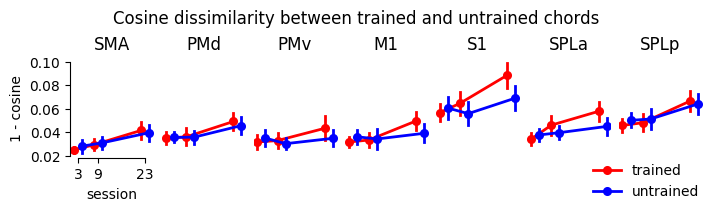

In [24]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Cosine dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/cosine_mean.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.199836   15  0.844293  [-0.05, 0.04]   SMA        3
3  -0.237246   15  0.815675  [-0.04, 0.03]   PMd        3
6  -0.489852   15  0.631325  [-0.05, 0.03]   PMv        3
9  -0.405120   15  0.691108  [-0.06, 0.04]    M1        3
12 -0.140027   15  0.890501  [-0.05, 0.04]    S1        3
15 -0.630833   15  0.537644  [-0.06, 0.03]  SPLa        3
18 -0.683744   15  0.504563  [-0.06, 0.03]  SPLp        3
1  -0.450583   15  0.658735  [-0.04, 0.03]   SMA        9
4  -0.500050   15  0.624296  [-0.04, 0.03]   PMd        9
7  -0.005777   15  0.995466  [-0.04, 0.04]   PMv        9
10  0.074932   15  0.941259  [-0.04, 0.04]    M1        9
13  1.040655   15  0.314520  [-0.02, 0.07]    S1        9
16  0.824878   15  0.422365  [-0.02, 0.05]  SPLa        9
19 -0.367968   15  0.718038  [-0.04, 0.03]  SPLp        9
2   0.074789   15  0.941371  [-0.05, 0.06]   SMA       23
5   0.695185   15  0.497568  [-0.02, 0.05]   PMd       23
8   0.998607  

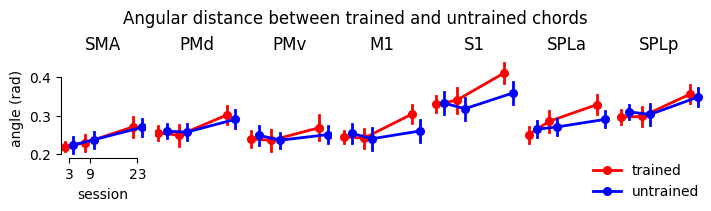

In [39]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

dist_chord_sess['theta'] = np.arccos(1 - dist_chord_sess.cosine)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Angular distance between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

# Distribution of angular distance and cosine similarity across participants (session 23)
Angle and cosine carry the same information -- $\theta = \arccos(\cos)$, with the `cosine` column of the tsv holding the dissimilarity $1 - \cos$ -- but the arccos stretches the top of the similarity range, so participants whose patterns are nearly collinear are pulled further apart in angle than in cosine. The two cells below show the same 16 participants under both parametrisations: trained chords sit at a wider angle (lower cosine similarity) than untrained ones in M1, S1 and SPLa, and the two metrics do not flag exactly the same ROIs (M1 reaches p < .05 for the angle only).

metric  roi        T  dof    p_val          CI95
cosine  SMA 0.270175   15 0.790707 [-0.01, 0.02]
cosine  PMd 0.698487   15 0.495560 [-0.01, 0.01]
cosine  PMv 1.516005   15 0.150307  [-0.0, 0.02]
cosine   M1 1.997089   15 0.064291  [-0.0, 0.02]
cosine   S1 2.364419   15 0.031969   [0.0, 0.04]
cosine SPLa 2.216437   15 0.042539   [0.0, 0.03]
cosine SPLp 0.314128   15 0.757750 [-0.01, 0.02]
 theta  SMA 0.074789   15 0.941371 [-0.05, 0.06]
 theta  PMd 0.695185   15 0.497568 [-0.02, 0.05]
 theta  PMv 0.998607   15 0.333823 [-0.02, 0.06]
 theta   M1 2.291462   15 0.036827   [0.0, 0.08]
 theta   S1 2.349533   15 0.032908    [0.0, 0.1]
 theta SPLa 2.448503   15 0.027121  [0.01, 0.07]
 theta SPLp 0.343962   15 0.735649 [-0.04, 0.05]


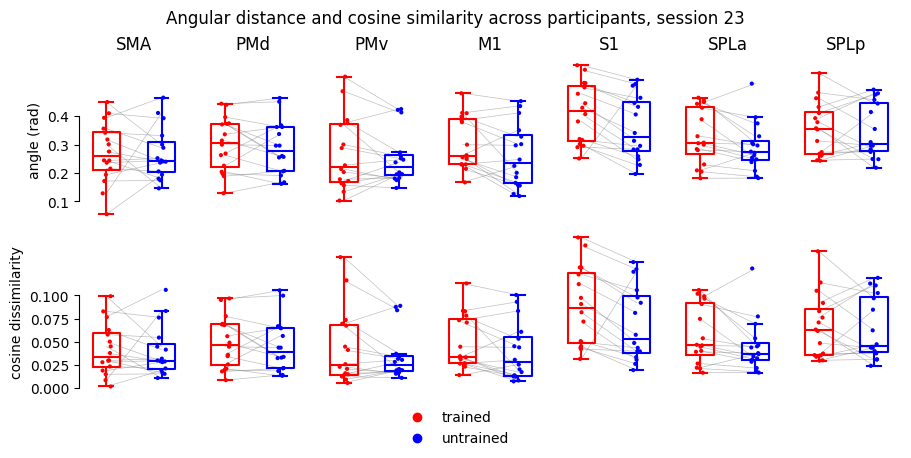

In [42]:
session = 23

dist_23 = dist_chord_sess[dist_chord_sess.session == session].copy()
dist_23['theta']   = np.arccos(1 - dist_23.cosine)    # angular distance, same convention as the cells above

metrics = [('theta', 'angle (rad)'), ('cosine', 'cosine dissimilarity')]

fig, axs = plt.subplots(len(metrics), len(rois), sharex=True, sharey='row', figsize=(9, 4.5), constrained_layout=True)

for m, (metric, ylabel) in enumerate(metrics):
    for r, roi in enumerate(rois):
        ax = axs[m, r]
        d  = dist_23[dist_23.roi == roi]
        # one grey line per participant, so the trained/untrained comparison stays paired
        paired = d.pivot(index='sn', columns='chord', values=metric).reindex(columns=hue_order).dropna()
        ax.plot([0, 1], paired.to_numpy().T, color='grey', lw=.5, alpha=.5, zorder=0)
        sb.boxplot(data=d, ax=ax, x='chord', y=metric, order=hue_order, hue='chord', hue_order=hue_order,
                   palette=palette, fill=False, width=.5, showfliers=False, legend=False)
        sb.stripplot(data=d, ax=ax, x='chord', y=metric, order=hue_order, hue='chord', hue_order=hue_order,
                     palette=palette, size=3, jitter=.08, legend=False)
        ax.set_xlabel(None)
        ax.set_title(roi) if m == 0 else None
        ax.tick_params(bottom=False, labelbottom=False)
        if r > 0:
            sb.despine(ax=ax, left=True, bottom=True)
            ax.tick_params(left=False)
            ax.set_ylabel(None)
        else:
            sb.despine(ax=ax, bottom=True, trim=True)
            ax.set_ylabel(ylabel)

custom_legend(fig, hue_order, palette, loc='outside lower center', kind='point')

fig.suptitle(f'Angular distance and cosine similarity across participants, session {session}')

ttest = pd.concat([ttest_im_sess(dist_23, rois, y=metric, x='session', hue='chord', hue_order=hue_order).assign(metric=metric)
                   for metric, _ in metrics])
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['metric', 'roi'], inplace=True)

print(ttest[['metric', 'roi', 'T', 'dof', 'p_val', 'CI95']].to_string(index=False))

fig.savefig(f'figures/angle_cosine_distribution_{session}.pdf')

plt.show()

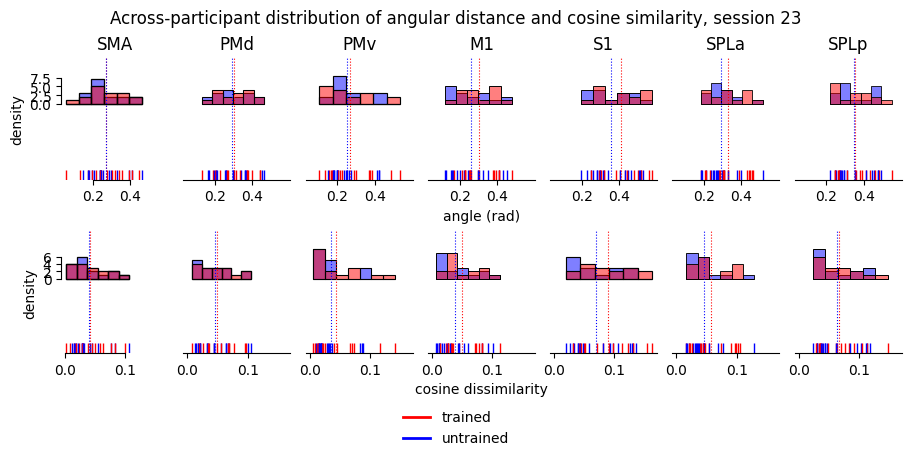

In [45]:
fig, axs = plt.subplots(len(metrics), len(rois), sharex='row', sharey='row', figsize=(9, 4.5), constrained_layout=True)

for m, (metric, xlabel) in enumerate(metrics):
    for r, roi in enumerate(rois):
        ax = axs[m, r]
        d  = dist_23[dist_23.roi == roi]
        # sb.kdeplot(data=d, ax=ax, x=metric, hue='chord', hue_order=hue_order, palette=palette,
        #            fill=True, alpha=.2, lw=1.5, common_norm=False, cut=0, legend=False)
        sb.rugplot(data=d, ax=ax, x=metric, hue='chord', hue_order=hue_order, palette=palette, height=.08, lw=1, legend=False)
        sb.histplot(data=d, ax=ax, x=metric, hue='chord', hue_order=hue_order, palette=palette, legend=False)
        for chord, color in zip(hue_order, palette):
            ax.axvline(d[d.chord == chord][metric].mean(), color=color, lw=.8, ls=':')   # group mean
        ax.set_title(roi) if m == 0 else None
        ax.set_xlabel(xlabel) if r == len(rois) // 2 else ax.set_xlabel(None)
        if r > 0:
            sb.despine(ax=ax, left=True)
            ax.tick_params(left=False)
            ax.set_ylabel(None)
        else:
            sb.despine(ax=ax, trim=True)
            ax.set_ylabel('density')

custom_legend(fig, hue_order, palette, loc='outside lower center', kind='line')

fig.suptitle(f'Across-participant distribution of angular distance and cosine similarity, session {session}')

fig.savefig(f'figures/angle_cosine_distribution_kde_{session}.pdf')

plt.show()

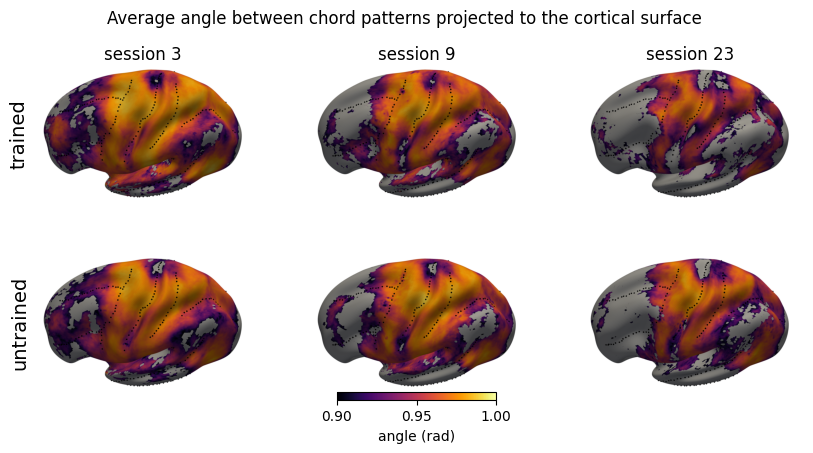

In [28]:
# theta is an angle in radians, so it lives in a different range than the crossnobis map above
thresh = .9
vmin, vmax = .9, 1
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_cosine.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('cosine-trained')
    untr_col = cols.index('cosine-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='cosine')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Cosine similarity between chord patterns projected to the cortical surface')

fig.savefig('figures/angle_searchlight.pdf')

plt.show()

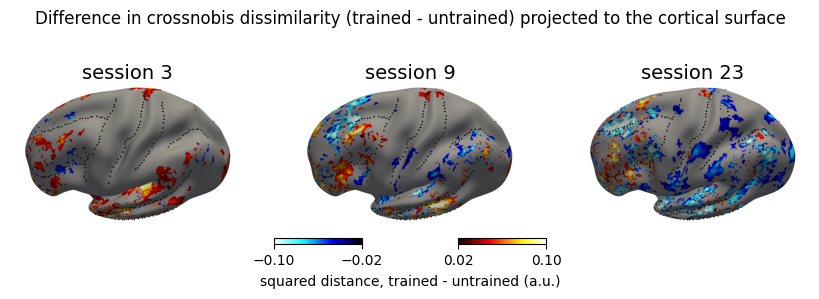

In [31]:
thresh = .02
vmin, vmax = -.1, .1

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3), )

for s, session in enumerate(gl.sessions):
    ax       = axs[s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_cosine_diff.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    diff_col = cols.index('trained-untrained')
    plot_surf(fig, ax, gifti, H, cmap=cmap, col=diff_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax.set_title(f'session {session}', fontsize=14)

cold_half = LinearSegmentedColormap.from_list('cold_half', combined[:128])
hot_half  = LinearSegmentedColormap.from_list('hot_half', combined[128:])

sm_neg   = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=-thresh), cmap=cold_half)
cax_neg  = fig.add_axes([.33, .2, .11, .02])
cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])

sm_pos   = plt.cm.ScalarMappable(norm=Normalize(vmin=thresh, vmax=vmax), cmap=hot_half)
cax_pos  = fig.add_axes([.56, .2, .11, .02])
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])

fig.supxlabel('squared distance, trained - untrained (a.u.)', fontsize=10, y=.05)

fig.suptitle('Difference in crossnobis dissimilarity (trained - untrained) projected to the cortical surface')

plt.subplots_adjust(left=0, right=1, bottom=.1, top=.9, hspace=0)

fig.savefig('figures/crossnobis_diff_searchlight.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.194428   15  0.848450  [-0.02, 0.02]   SMA        3
3  -0.223989   15  0.825788  [-0.02, 0.01]   PMd        3
6  -0.435434   15  0.669448  [-0.03, 0.02]   PMv        3
9  -1.250936   15  0.230118  [-0.05, 0.01]    M1        3
12 -0.986546   15  0.339512  [-0.05, 0.02]    S1        3
15 -0.923744   15  0.370242  [-0.04, 0.02]  SPLa        3
18 -0.632222   15  0.536760  [-0.04, 0.02]  SPLp        3
1   0.299264   15  0.768845  [-0.02, 0.02]   SMA        9
4  -1.093291   15  0.291513  [-0.03, 0.01]   PMd        9
7   0.062010   15  0.951373  [-0.03, 0.03]   PMv        9
10  0.618788   15  0.545340  [-0.03, 0.05]    M1        9
13  1.305538   15  0.211380  [-0.01, 0.05]    S1        9
16  0.155106   15  0.878806  [-0.02, 0.02]  SPLa        9
19  0.162288   15  0.873245  [-0.02, 0.02]  SPLp        9
2   0.296293   15  0.771069  [-0.02, 0.03]   SMA       23
5   0.407077   15  0.689701  [-0.02, 0.03]   PMd       23
8  -0.525692  

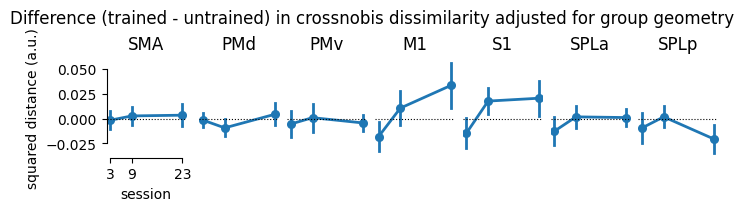

In [ ]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist_ancova_crossnobis = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='crossnobis')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_crossnobis, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in crossnobis dissimilarity adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_crossnobis, rois, y='adjusted', x='session',)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val          CI95   roi  session
0   5.764028   15  0.000037  [0.67, 1.45]   SMA        3
3   5.393898   15  0.000075  [0.62, 1.42]   PMd        3
6   6.242420   15  0.000016  [0.67, 1.36]   PMv        3
9   4.889913   15  0.000196  [0.58, 1.47]    M1        3
12  5.090118   15  0.000133  [0.59, 1.45]    S1        3
15  5.478979   15  0.000064  [0.61, 1.39]  SPLa        3
18  5.878529   15  0.000030  [0.65, 1.38]  SPLp        3
1   4.037780   15  0.001074   [0.5, 1.61]   SMA        9
4   4.864689   15  0.000206  [0.58, 1.49]   PMd        9
7   4.519499   15  0.000407  [0.48, 1.33]   PMv        9
10  5.042916   15  0.000146  [0.51, 1.25]    M1        9
13  5.320363   15  0.000086  [0.56, 1.31]    S1        9
16  4.734098   15  0.000266  [0.54, 1.44]  SPLa        9
19  4.561398   15  0.000375  [0.48, 1.32]  SPLp        9
2   2.861917   15  0.011877  [0.28, 1.92]   SMA       23
5   4.238798   15  0.000715  [0.51, 1.53]   PMd       23
8   3.037227   15  0.008317   [

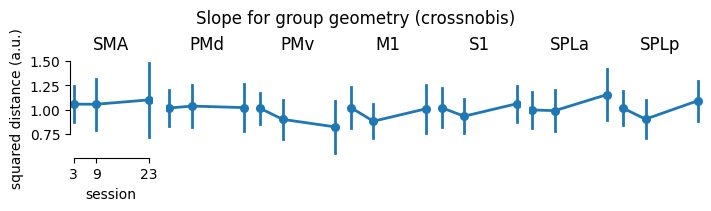

In [55]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_crossnobis, rois, y='slope', x='session', kind='point', estimator='mean', dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (crossnobis)')

ttest = ttest_im_sess(dist_ancova_crossnobis, rois, y='slope', x='session',)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.577749   15  0.572005  [-0.01, 0.01]   SMA        3
3  -0.091883   15  0.928007  [-0.01, 0.01]   PMd        3
6  -0.740864   15  0.470216  [-0.02, 0.01]   PMv        3
9  -0.921753   15  0.371246  [-0.01, 0.01]    M1        3
12 -0.201142   15  0.843289  [-0.01, 0.01]    S1        3
15 -0.472739   15  0.643205  [-0.01, 0.01]  SPLa        3
18 -0.416454   15  0.682975  [-0.01, 0.01]  SPLp        3
1   0.366889   15  0.718826  [-0.01, 0.01]   SMA        9
4   0.426952   15  0.675479  [-0.01, 0.02]   PMd        9
7   0.548315   15  0.591543  [-0.01, 0.01]   PMv        9
10  0.264197   15  0.795223  [-0.01, 0.02]    M1        9
13  1.493879   15  0.155944  [-0.01, 0.03]    S1        9
16  1.441757   15  0.169923   [-0.0, 0.02]  SPLa        9
19 -0.152456   15  0.880859  [-0.02, 0.01]  SPLp        9
2   0.697353   15  0.496249  [-0.01, 0.02]   SMA       23
5   1.439859   15  0.170451   [-0.0, 0.02]   PMd       23
8   1.871138  

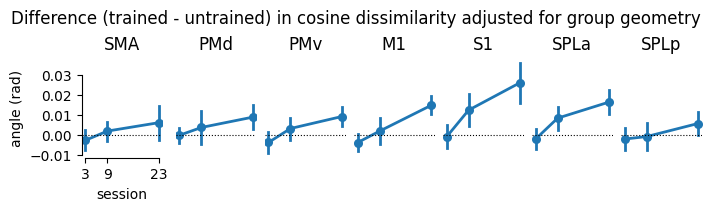

In [50]:
dist_ancova_cos = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='cosine')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_cos, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in cosine dissimilarity adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_cos, rois, y='adjusted', x='session',)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

            T  dof         p_val          CI95   roi  session
0    6.797092   15  6.022385e-06   [0.73, 1.4]   SMA        3
3    8.443332   15  4.404303e-07  [0.77, 1.29]   PMd        3
6    5.390503   15  7.501932e-05  [0.62, 1.43]   PMv        3
9    7.608099   15  1.589523e-06   [0.73, 1.3]    M1        3
12   7.783882   15  1.204516e-06  [0.72, 1.27]    S1        3
15   8.313947   15  5.343001e-07  [0.74, 1.25]  SPLa        3
18  10.396378   15  2.989179e-08  [0.81, 1.23]  SPLp        3
1    6.368549   15  1.261895e-05  [0.79, 1.58]   SMA        9
4    6.171346   15  1.788714e-05  [0.69, 1.42]   PMd        9
7    5.999635   15  2.434259e-05  [0.63, 1.32]   PMv        9
10   4.735506   15  2.654837e-04   [0.57, 1.5]    M1        9
13   6.306044   15  1.408626e-05  [0.68, 1.37]    S1        9
16   6.677093   15  7.389637e-06  [0.78, 1.51]  SPLa        9
19   6.832603   15  5.670707e-06  [0.71, 1.35]  SPLp        9
2    6.653399   15  7.696061e-06   [1.08, 2.1]   SMA       23
5    7.0

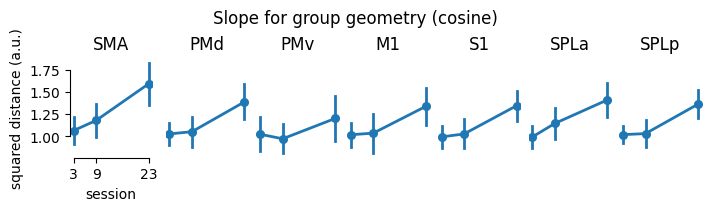

In [56]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_cos, rois, y='slope', x='session', kind='point', estimator='mean', dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (cosine)')

ttest = ttest_im_sess(dist_ancova_cos, rois, y='slope', x='session',)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

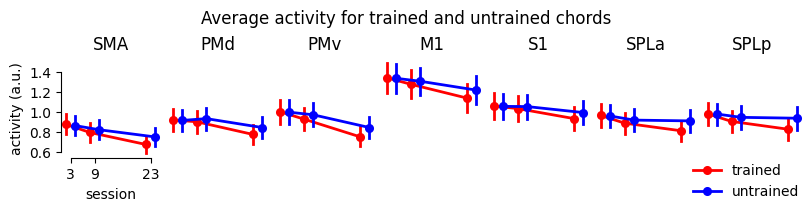

In [51]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

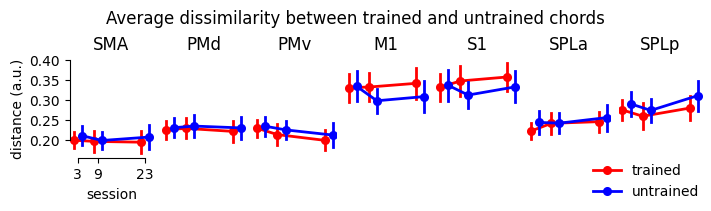

In [52]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('distance (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

           T  dof     p_val           CI95   roi  session
0        NaN   15       NaN     [nan, nan]   SMA        3
3        NaN   15       NaN     [nan, nan]   PMd        3
6        NaN   15       NaN     [nan, nan]   PMv        3
9        NaN   15       NaN     [nan, nan]    M1        3
12       NaN   15       NaN     [nan, nan]    S1        3
15       NaN   15       NaN     [nan, nan]  SPLa        3
18       NaN   15       NaN     [nan, nan]  SPLp        3
7   0.311292   15  0.759863  [-0.04, 0.06]   PMv        9
13  2.978445   14  0.009968   [0.01, 0.07]    S1        9
10  1.634585   14  0.124413  [-0.01, 0.09]    M1        9
4   0.354260   14  0.728423  [-0.02, 0.03]   PMd        9
1   1.132243   15  0.275308  [-0.02, 0.05]   SMA        9
16  1.624871   15  0.125012  [-0.01, 0.07]  SPLa        9
19  0.670176   15  0.512932  [-0.03, 0.06]  SPLp        9
5   1.173090   15  0.259052  [-0.01, 0.04]   PMd       23
2   1.413012   15  0.178066  [-0.01, 0.05]   SMA       23
14  2.975723  

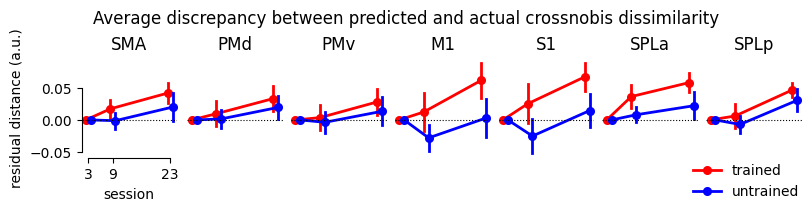

In [53]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('residual distance (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual crossnobis dissimilarity')

ttest = ttest_im_sess(scaling, rois, y='residual', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()